In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gurobipy import Model, GRB, quicksum

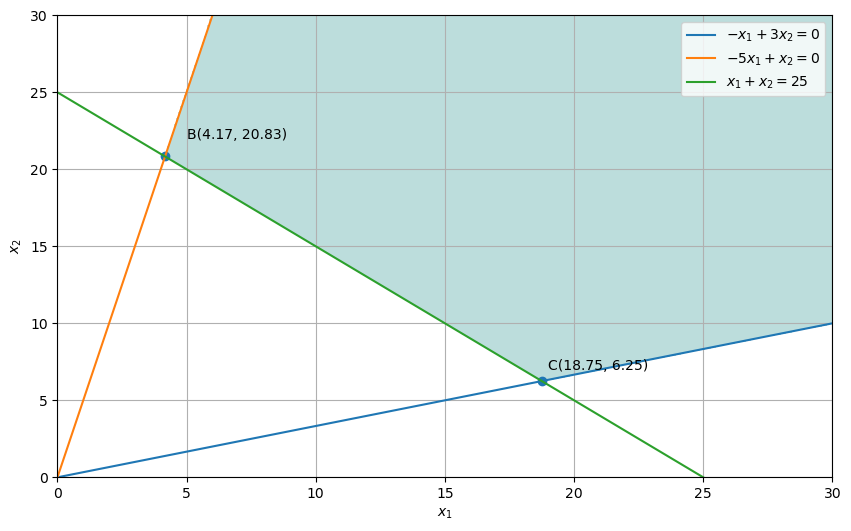

In [7]:
x = np.linspace(0, 30, 400)

y1 = x / 3
y2 = 5 * x
y3 = 25 - x

plt.figure(figsize=(10, 6))

plt.plot(x, y1, label=r'$-x_1 + 3x_2 = 0$')
plt.plot(x, y2, label=r'$-5x_1 + x_2 = 0$')
plt.plot(x, y3, label=r'$x_1 + x_2 = 25$')

X1, X2 = np.meshgrid(np.linspace(0, 30, 400),
                     np.linspace(0, 30, 400))

feasible = (
    (-X1 + 3*X2 >= 0) &
    (-5*X1 + X2 <= 0) &
    (X1 + X2 >= 25) &
    (X1 >= 0) &
    (X2 >= 0)
)

plt.contourf(X1, X2, feasible, levels=[0.5, 1], alpha=0.3)

B = (25/6, 125/6)
C = (75/4, 25/4)

plt.scatter([B[0], C[0]], [B[1], C[1]]),
plt.annotate(f'B({B[0]:.2f}, {B[1]:.2f})', xy=B, xytext=(5, 22))
plt.annotate(f'C({C[0]:.2f}, {C[1]:.2f})', xy=C, xytext=(19, 7))

plt.xlim(0, 30)
plt.ylim(0, 30)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.grid(True)
plt.legend()
plt.show()

In [8]:
def solve_1d_phase1_solver():
    model = Model("Phase_I_Model")
    model.setParam("OutputFlag", 0)
    #normal variables
    x1 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x1")
    x2 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x2")
    
    #slack variables
    x3 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x3")  
    x4 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x4")  
    x5 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x5")  
    
    #artificial variables
    x6 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x6")  
    x7 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x7")  

    model.setObjective(x6 + x7, GRB.MINIMIZE)

    model.addConstr(-x1 + 3*x2 - x3 + x6 == 0, name="constraint_1")
    model.addConstr(-5*x1 + x2 + x4 == 0, name="constraint_2")
    model.addConstr(x1 + x2 - x5 + x7 == 25, name="constraint_3")

    model.optimize()

    if model.status == GRB.OPTIMAL:
        print("----- PHASE I SOLVER RESULT -----")
        print(f"Phase I Objective Value W*: {model.objVal:.2f}")

        print(f"x1 = {x1.X:.3f}")
        print(f"x2 = {x2.X:.3f}")
        print(f"x3 = {x3.X:.3f}")
        print(f"x4 = {x4.X:.3f}")
        print(f"x5 = {x5.X:.3f}")
        print(f"x6 = {x6.X:.3f}")
        print(f"x7 = {x7.X:.3f}")

        if abs(model.objVal) < 1e-9:
            print("The original problem is feasible.")
        else:
            print("The original problem is infeasible.")

        return model.objVal

phase1_obj_1d = solve_1d_phase1_solver()

----- PHASE I SOLVER RESULT -----
Phase I Objective Value W*: 0.00
x1 = 18.750
x2 = 6.250
x3 = 0.000
x4 = 87.500
x5 = 0.000
x6 = 0.000
x7 = 0.000
The original problem is feasible.


In [9]:
def solve_1e_big_m():
    model = Model("Part_1e_Big_M_Model")
    model.setParam("OutputFlag", 0)

    M = 10**4

    x1 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x1")
    x2 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x2")

    #slack variables
    x3 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x3")  # surplus for constraint 1
    x4 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x4")  # slack for constraint 2
    x5 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x5")  # surplus for constraint 3

    # Artificial variables
    x6 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x6")  # artificial for constraint 1
    x7 = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name="x7")  # artificial for constraint 3

    #objective function
    model.setObjective(
        16*x1 + 20*x2 + M*x6 + M*x7,
        GRB.MINIMIZE
    )

    model.addConstr(-x1 + 3*x2 - x3 + x6 == 0, name="constraint_1")
    model.addConstr(-5*x1 + x2 + x4 == 0, name="constraint_2")
    model.addConstr(x1 + x2 - x5 + x7 == 25, name="constraint_3")

    model.optimize()

    if model.status == GRB.OPTIMAL:
        print("----- BIG-M RESULT -----")
        print(f"Objective Value: {model.objVal:.2f}")
        print(f"x1 = {x1.X:.3f}")
        print(f"x2 = {x2.X:.3f}")
        print(f"x3 = {x3.X:.3f}")
        print(f"x4 = {x4.X:.3f}")
        print(f"x5 = {x5.X:.3f}")
        print(f"x6 = {x6.X:.3f}")
        print(f"x7 = {x7.X:.3f}")

        return model.objVal

big_m_obj = solve_1e_big_m()

----- BIG-M RESULT -----
Objective Value: 425.00
x1 = 18.750
x2 = 6.250
x3 = 0.000
x4 = 87.500
x5 = 0.000
x6 = 0.000
x7 = 0.000


In [10]:
excel_file = 'Exam Schedule Data.xlsx'

courses_df = pd.read_excel(excel_file, sheet_name='Courses')
capacity_df = pd.read_excel(excel_file, sheet_name='Capacity')
availability_df = pd.read_excel(excel_file, sheet_name='Proctor Availability')
costs_df = pd.read_excel(excel_file, sheet_name='Proctor Costs')

C = courses_df['course_id'].tolist()
R = capacity_df['room_id'].tolist()
P = availability_df['proctor_id'].unique().tolist()
S = courses_df['slot_id'].unique().tolist()

courses_df = courses_df.set_index('course_id')
capacity_df = capacity_df.set_index('room_id')
availability_df = availability_df.set_index(['proctor_id', 'slot_id'])
costs_df = costs_df.set_index(['proctor_id', 'room_id'])

In [11]:
def solve_exam_scheduling_excel():
    model = Model("Part2b_Exam_Scheduling")
    model.setParam('OutputFlag', 0)

    y = model.addVars(C, R, vtype=GRB.BINARY, name="y")
    x = model.addVars(P, C, R, vtype=GRB.BINARY, name="x")
    
    model.setObjective(
        quicksum(int(costs_df.loc[(p, r), 'assignment_cost']) * x[p, c, r]
            for p in P for c in C for r in R),
        GRB.MINIMIZE
    )
    
    for c in C:
        model.addConstr(quicksum(y[c, r] for r in R) == 1,f"Assign_Course_{c}")
        
    for c in C:
        student_count = int(courses_df.loc[c, 'student_count'])
        for r in R:
            room_cap = int(capacity_df.loc[r, 'capacity'])
            model.addConstr(student_count * y[c, r] <= room_cap,f"Cap_{c}_{r}")
            
    for s in S:
        courses_in_slot = courses_df[courses_df['slot_id'] == s].index.tolist()
        for r in R:
            model.addConstr(quicksum(y[c, r] for c in courses_in_slot) <= 1,f"One_Exam_Per_Room_Slot_{s}_{r}")
            
    for c in C:
        req_proctors = int(courses_df.loc[c, 'required_proctors'])
        for r in R:
            model.addConstr(quicksum(x[p, c, r] for p in P) == req_proctors * y[c, r],f"Req_Proctors_{c}_{r}")
            
    for p in P:
        for c in C:
            for r in R:
                model.addConstr(x[p, c, r] <= y[c, r],f"Link_{p}_{c}_{r}")
            
    for p in P:
        for c in C:
            slot = courses_df.loc[c, 'slot_id']
            is_avail = int(availability_df.loc[(p, slot), 'is_available'])
            for r in R:
                model.addConstr(x[p, c, r] <= is_avail,f"TA_Availability_{p}_{c}_{r}")
                    
    for p in P:
        for s in S:
            courses_in_slot = courses_df[courses_df['slot_id'] == s].index.tolist()
            model.addConstr(quicksum(x[p, c, r] for c in courses_in_slot for r in R) <= 1,f"TA_Max_One_Per_Slot_{p}_{s}")

    model.optimize()
    
    if model.status == GRB.OPTIMAL:
        obj_b = model.objVal
        print(f"Part 2b Total Cost: {obj_b:.2f}")
        return obj_b

obj_b = solve_exam_scheduling_excel()

Part 2b Total Cost: 189750.00


In [12]:
#2c
def solve_exam_scheduling_continuous():
    model = Model("Exam_Scheduling_Continuous")
    model.setParam('OutputFlag', 0)
    
    y = model.addVars(C, R, vtype=GRB.CONTINUOUS, lb=0.0, ub=1.0, name="y")
    x = model.addVars(P, C, R, vtype=GRB.CONTINUOUS, lb=0.0, ub=1.0, name="x")
    
    model.setObjective(
        quicksum(costs_df.loc[(p, r), 'assignment_cost'] * x[p, c, r]
            for p in P for c in C for r in R
            if (p, r) in costs_df.index),
        GRB.MINIMIZE
    )
    
    for c in C:
        model.addConstr(quicksum(y[c, r] for r in R) == 1, f"Assign_Course_{c}")
        
    for c in C:
        student_count = courses_df.loc[c, 'student_count']
        for r in R:
            room_cap = capacity_df.loc[r, 'capacity']
            model.addConstr(student_count * y[c, r] <= room_cap, f"Cap_{c}_{r}")
            
    for s in S:
        courses_in_slot = courses_df[courses_df['slot_id'] == s].index.tolist()
        for r in R:
            model.addConstr(quicksum(y[c, r] for c in courses_in_slot) <= 1,f"One_Exam_Per_Room_Slot_{s}_{r}")
            
    for c in C:
        req_proctors = courses_df.loc[c, 'required_proctors']
        for r in R:
            model.addConstr(quicksum(x[p, c, r] for p in P) >= req_proctors * y[c, r],f"Req_Proctors_{c}_{r}")

    for p in P:
        for c in C:
            for r in R:
                model.addConstr(x[p, c, r] <= y[c, r],f"Link_{p}_{c}_{r}")
            
    for p in P:
        for c in C:
            slot = courses_df.loc[c, 'slot_id']
            if (p, slot) in availability_df.index and availability_df.loc[(p, slot), 'is_available'] == 0:
                for r in R:
                    model.addConstr(x[p, c, r] == 0, f"TA_Unavailable_{p}_{c}_{r}")
                    
    for p in P:
        for s in S:
            courses_in_slot = courses_df[courses_df['slot_id'] == s].index.tolist()
            model.addConstr(quicksum(x[p, c, r] for c in courses_in_slot for r in R) <= 1, f"TA_Max_One_Per_Slot_{p}_{s}")

    model.optimize()
    
    if model.status == GRB.OPTIMAL:
        print(f"Part 2c Objective: {model.objVal:.2f}")

solve_exam_scheduling_continuous()

Part 2c Objective: 189750.00


In [13]:
#2d
def solve_part2_d():
    model_d = Model("Part2d_Exam_Schedule")
    model_d.setParam('OutputFlag', 0)
    
    y_d = model_d.addVars(C, R, vtype=GRB.BINARY, name="y")
    x_d = model_d.addVars(P, C, R, vtype=GRB.BINARY, name="x")
    
    model_d.setObjective(
        quicksum(
            costs_df.loc[(p, r), 'assignment_cost'] * x_d[p, c, r]
            for p in P for c in C for r in R
            if (p, r) in costs_df.index
        ),
        GRB.MINIMIZE
    )
    
    for c in C:
        model_d.addConstr(quicksum(y_d[c, r] for r in R) == 1, f"Assign_{c}")
    
    for c in C:
        student_count = courses_df.loc[c, 'student_count']
        for r in R:
            room_cap = capacity_df.loc[r, 'capacity']
            model_d.addConstr(student_count * y_d[c, r] <= room_cap, f"Capacity_{c}_{r}")
    
    for c in C:
        req_proctors = courses_df.loc[c, 'required_proctors']
        for r in R:
            model_d.addConstr(quicksum(x_d[p, c, r] for p in P) >= req_proctors * y_d[c, r],f"ProctorRequirement_{c}_{r}")
    
    for p in P:
        for c in C:
            for r in R:
                model_d.addConstr(x_d[p, c, r] <= y_d[c, r], f"Link_{p}_{c}_{r}")
    
    for s in S:
        courses_in_slot = courses_df[courses_df['slot_id'] == s].index.tolist()
        for r in R:
            model_d.addConstr(quicksum(y_d[c, r] for c in courses_in_slot) <= 1,f"RoomSlot_{s}_{r}")
    
    for p in P:
        for c in C:
            slot = courses_df.loc[c, 'slot_id']
            for r in R:
                if availability_df.loc[(p, slot), 'is_available'] == 0:
                    model_d.addConstr(x_d[p, c, r] == 0, f"Availability_{p}_{c}_{r}")
    
    for p in P:
        for s in S:
            courses_in_slot = courses_df[courses_df['slot_id'] == s].index.tolist()
            model_d.addConstr(quicksum(x_d[p, c, r] for c in courses_in_slot for r in R) <= 1,f"ProctorSlot_{p}_{s}")
    
    model_d.optimize()
    
    if model_d.status == GRB.OPTIMAL:
        print("\nTA073 Exam-Day Schedule:")
        for c in C:
            for r in R:
                if x_d["TA073", c, r].X > 0.5:
                    slot = courses_df.loc[c, 'slot_id']
                    print(f"TA073 -> Exam: {c}, Time Slot: {slot}, Room: {r}")
    
        print("\nSCI107 Door Schedule:")
        for c in C:
            if y_d[c, "SCI107"].X > 0.5:
                slot = courses_df.loc[c, 'slot_id']
                print(f"SCI107 -> Exam: {c}, Time Slot: {slot}")
solve_part2_d()


TA073 Exam-Day Schedule:
TA073 -> Exam: INDR209, Time Slot: T6, Room: ENG109
TA073 -> Exam: INDR269, Time Slot: T1, Room: SOS101

SCI107 Door Schedule:
SCI107 -> Exam: INDR249, Time Slot: T3
SCI107 -> Exam: INDR282, Time Slot: T4
SCI107 -> Exam: INDR285, Time Slot: T6
SCI107 -> Exam: INDR301, Time Slot: T2
SCI107 -> Exam: INDR313, Time Slot: T5


In [14]:
#2e

def solve_part2e(obj_b):
    model_e = Model("Part2e_Disciplinary_Model")
    model_e.setParam('OutputFlag', 0)
    
    y_e = model_e.addVars(C, R, vtype=GRB.BINARY, name="y")
    x_e = model_e.addVars(P, C, R, vtype=GRB.BINARY, name="x")
    
    model_e.setObjective(
        quicksum(costs_df.loc[(p, r), 'assignment_cost'] * x_e[p, c, r]for p in P for c in C for r in R if (p, r) in costs_df.index),
        GRB.MINIMIZE
    )
    
    for c in C:
        model_e.addConstr(quicksum(y_e[c, r] for r in R) == 1,f"Assign_Course_{c}")
        
    for c in C:
        student_count = courses_df.loc[c, 'student_count']
        for r in R:
            room_cap = capacity_df.loc[r, 'capacity']
            model_e.addConstr(student_count * y_e[c, r] <= room_cap,f"Cap_{c}_{r}")
            
    for s in S:
        courses_in_slot = courses_df[courses_df['slot_id'] == s].index.tolist()
        for r in R:
            model_e.addConstr(quicksum(y_e[c, r] for c in courses_in_slot) <= 1,f"One_Exam_Per_Room_Slot_{s}_{r}")
            
    for c in C:
        req_proctors = courses_df.loc[c, 'required_proctors']
        for r in R:
            model_e.addConstr(quicksum(x_e[p, c, r] for p in P) >= req_proctors * y_e[c, r],f"Req_Proctors_{c}_{r}")

    for p in P:
        for c in C:
            for r in R:
                model_e.addConstr(x_e[p, c, r] <= y_e[c, r],f"Link_{p}_{c}_{r}")
            
    for p in P:
        for c in C:
            slot = courses_df.loc[c, 'slot_id']
            
            if (p, slot) in availability_df.index and availability_df.loc[(p, slot), 'is_available'] == 0:
                for r in R:
                    model_e.addConstr(x_e[p, c, r] == 0,f"TA_Unavailable_{p}_{c}_{r}")
                    
    for p in P:
        for s in S:
            courses_in_slot = courses_df[courses_df['slot_id'] == s].index.tolist()
            model_e.addConstr(
                quicksum(x_e[p, c, r] for c in courses_in_slot for r in R) <= 1,
                f"TA_Max_One_Per_Slot_{p}_{s}")

    disciplinary_TAs = ["TA018", "TA055", "TA040", "TA065"]

    for c in C:
        for r in R:
            model_e.addConstr(quicksum(x_e[p, c, r] for p in disciplinary_TAs) <= 1,f"Disciplinary_{c}_{r}")

    model_e.optimize()
    
    if model_e.status == GRB.OPTIMAL:
        obj_e = model_e.objVal
        increase_e = obj_e - obj_b
        
        print("PART 2e RESULT")
        print(f"Part 2b Objective Value: {obj_b:.2f}")
        print(f"Part 2e New Objective Value: {obj_e:.2f}")
        print(f"Increase Relative to Part 2b: {increase_e:.2f}")

        return obj_e


obj_e = solve_part2e(obj_b)

PART 2e RESULT
Part 2b Objective Value: 189750.00
Part 2e New Objective Value: 189750.00
Increase Relative to Part 2b: 0.00


In [15]:
# 2f
def solve_part2f(obj_b):
    bonus_df = pd.read_excel(excel_file, sheet_name='Bonus')

    model_f = Model("Part2f_Bonus_Model")
    model_f.setParam('OutputFlag', 0)

    x_f = model_f.addVars(C, R, vtype=GRB.BINARY, name="x")
    y_f = model_f.addVars(P, C, R, vtype=GRB.BINARY, name="y")

    model_f.setObjective(
        quicksum(
            costs_df.loc[(p, r), 'assignment_cost'] * y_f[p, c, r]
            for p in P for c in C for r in R
            if (p, r) in costs_df.index
        ),
        GRB.MINIMIZE
    )

    for c in C:
        model_f.addConstr(quicksum(x_f[c, r] for r in R) == 1,f"Assign_{c}")

    for c in C:
        student_count = courses_df.loc[c, 'student_count']
        for r in R:
            room_cap = capacity_df.loc[r, 'capacity']
            model_f.addConstr(student_count * x_f[c, r] <= room_cap,f"Capacity_{c}_{r}")

    for c in C:
        required = courses_df.loc[c, 'required_proctors']
        for r in R:
            model_f.addConstr(quicksum(y_f[p, c, r] for p in P) >= required * x_f[c, r],f"ProctorRequirement_{c}_{r}")

    for p in P:
        for c in C:
            for r in R:
                model_f.addConstr(y_f[p, c, r] <= x_f[c, r],f"Link_{p}_{c}_{r}")

    for s in S:
        courses_in_slot = courses_df[courses_df['slot_id'] == s].index.tolist()
        for r in R:
            model_f.addConstr(quicksum(x_f[c, r] for c in courses_in_slot) <= 1,f"RoomSlot_{s}_{r}")

    for p in P:
        for c in C:
            slot = courses_df.loc[c, 'slot_id']
            for r in R:
                if availability_df.loc[(p, slot), 'is_available'] == 0:
                    model_f.addConstr(y_f[p, c, r] == 0,f"Availability_{p}_{c}_{r}")

    for p in P:
        for s in S:
            courses_in_slot = courses_df[courses_df['slot_id'] == s].index.tolist()
            model_f.addConstr(quicksum(y_f[p, c, r] for c in courses_in_slot for r in R) <= 1,f"ProctorSlot_{p}_{s}")

    for row in bonus_df.itertuples(index=False):
        c = row.course_id
        r = row.room_id
        p = row.ta_id

        model_f.addConstr(x_f[c, r] == 1,f"FixedRoom_{c}_{r}")

        model_f.addConstr(y_f[p, c, r] == 1,f"FixedTA_{p}_{c}_{r}")

    model_f.optimize()

    if model_f.status == GRB.OPTIMAL:
        new_obj_f = model_f.objVal
        increase_f = new_obj_f - obj_b

        print("-----PART 2f RESULT-----")
        print(f"Part 2f New Objective Value: {new_obj_f:.2f}")
        print(f"Increase Relative to Part 2b: {increase_f:.2f}")

        return new_obj_f

obj_b = solve_exam_scheduling_excel()
obj_f = solve_part2f(obj_b)

Part 2b Total Cost: 189750.00
-----PART 2f RESULT-----
Part 2f New Objective Value: 200732.00
Increase Relative to Part 2b: 10982.00


In [16]:
#3b
df = pd.read_csv('Knapsack262.csv')
items = range(len(df))

def solve_knapsack_gurobi(model_type):
    model = Model(f"Knapsack_{model_type}")
    model.setParam('OutputFlag', 0)
    
    if model_type == 'Binary':
        x = model.addVars(items, vtype=GRB.BINARY, name="x")
    elif model_type == 'Integer':
        x = model.addVars(items, vtype=GRB.INTEGER, name="x")
    elif model_type == 'Continuous':
        x = model.addVars(items, vtype=GRB.CONTINUOUS, name="x")
    
    model.setObjective(quicksum(df.loc[i, 'value_dollar'] * x[i] for i in items), GRB.MAXIMIZE)
    
    model.addConstr(quicksum(df.loc[i, 'mass_kg'] * x[i] for i in items) <= 1262, "Mass")
    model.addConstr(quicksum(df.loc[i, 'volume_m3'] * x[i] for i in items) <= 1262, "Volume")
    
    model.optimize()
    
    return model.objVal

print(f"Binary Result: {solve_knapsack_gurobi('Binary'):.2f}")
print(f"Integer Result: {solve_knapsack_gurobi('Integer'):.2f}")
print(f"Continuous Result: {solve_knapsack_gurobi('Continuous'):.2f}")

Binary Result: 1761.00
Integer Result: 3317.00
Continuous Result: 3367.37


In [17]:
# 3c
def solve_dual_model():
    dual_model = Model("Dual_Knapsack")
    dual_model.setParam('OutputFlag', 0)
    
    y1 = dual_model.addVar(name="y1")
    y2 = dual_model.addVar(name="y2")
    
    dual_model.setObjective(1262 * y1 + 1262 * y2, GRB.MINIMIZE)
    
    for i in range(len(df)):
        dual_model.addConstr(df.loc[i, 'mass_kg'] * y1 + df.loc[i, 'volume_m3'] * y2 >= df.loc[i, 'value_dollar'], f"Dual_Constr_{i}")
    
    dual_model.optimize()
    print(f"\n--- Result of 3c ---")
    print(f"Dual Objective (W): {dual_model.objVal:.3f}")
    print(f"y1 (Mass Shadow Price): {y1.x:.3f}")
    print(f"y2 (Vol Shadow Price): {y2.x:.3f}")

solve_dual_model()


--- Result of 3c ---
Dual Objective (W): 3367.373
y1 (Mass Shadow Price): 1.237
y2 (Vol Shadow Price): 1.431


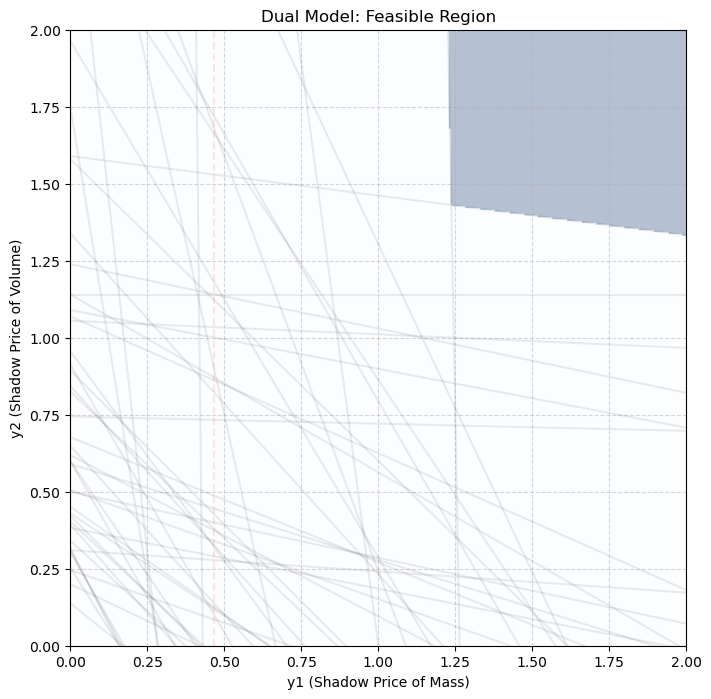

In [18]:
# 3d
def plot_dual_feasible_region():
    y1_range = np.linspace(0, 3, 500)
    y2_range = np.linspace(0, 3, 500)
    Y1, Y2 = np.meshgrid(y1_range, y2_range)
    
    feasible = np.ones_like(Y1, dtype=bool)
    
    for i in range(len(df)):
        constraint = (df.loc[i, 'mass_kg'] * Y1 + df.loc[i, 'volume_m3'] * Y2 >= df.loc[i, 'value_dollar'])
        feasible = feasible & constraint
    
    plt.figure(figsize=(10, 8))
    
    plt.imshow(feasible.astype(int), extent=(0, 3, 0, 3), origin='lower', cmap='Blues', alpha=0.3)
    
    for i in range(len(df)):
        v = df.loc[i, 'volume_m3']
        m = df.loc[i, 'mass_kg']
        val = df.loc[i, 'value_dollar']
        
        if v > 0:
            plt.plot(y1_range, (val - m * y1_range) / v, 'k-', alpha=0.08)
        elif m > 0:
            plt.axvline(x=val/m, color='r', linestyle='--', alpha=0.1)
            
    plt.xlabel('y1 (Shadow Price of Mass)')
    plt.ylabel('y2 (Shadow Price of Volume)')
    plt.title('Dual Model: Feasible Region')
    plt.xlim(0, 2)
    plt.ylim(0, 2)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

plot_dual_feasible_region()